In [1]:
import pandas as pd

In [2]:
from rdkit import Chem

In [3]:
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

In [4]:
print ("Pandas and RDKit imported successfully!")

Pandas and RDKit imported successfully!


In [5]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [6]:
import openpyxl

In [7]:
print("openpyxl version:", openpyxl.__version__)

openpyxl version: 3.1.5


In [8]:
import pandas as pd

In [9]:
df = pd.read_excel(
    "LPS-Induced NO QSAR.xlsx",
    sheet_name="Sheet 2"
)

In [10]:
print(df.head())

   ID Compound                                             Smiles  IC50 (μM)  \
0   1       K1  O=C(C(C(C)(C)C=C)=C1)OC2=C1C=C(C[C@@H](C(C)(O)...       0.52   
1   2       K2  O=C(C(C(C)(C)C=C)=C1)OC2=C1C=C(C[C@@H](O)C(C)(...       2.58   
2   3       K3  O=C(C(C(C)(C)C=C)=C1)OC2=C1C=C([C@H](O)[C@@H](...       1.06   
3   4       K4    O=C(C=C1)OC2=C1C=C(C/C=C(C)/C)C(O)=C2C/C=C(C)\C       5.49   
4   5       K5    O=C(C=C1)OC2=C1C=C(C[C@@H](OC)C(C)(O)C)C(OC)=C2       7.39   

   SD (μM)  pIC50 Ref  
0     0.05   6.28  R2  
1     0.10   5.88  R2  
2     0.07   5.97  R2  
3     0.13   5.26  R2  
4     0.16   5.13  R2  


In [11]:
print("\nNumber of compounds:", len(df))


Number of compounds: 34


In [12]:
from rdkit import Chem

In [13]:
df["Mol"] = df["Smiles"].apply(Chem.MolFromSmiles)

In [14]:
print("Valid molecules:", df["Mol"].notna().sum())

Valid molecules: 34


In [15]:
print("Invalid molecules:", df["Mol"].isna().sum())

Invalid molecules: 0


In [16]:
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

In [17]:
df["MolWt"] = df["Mol"].apply(Descriptors.MolWt)
df["LogP"] = df["Mol"].apply(Crippen.MolLogP)
df["TPSA"] = df["Mol"].apply(rdMolDescriptors.CalcTPSA)
df["HBD"] = df["Mol"].apply(Lipinski.NumHDonors)
df["HBA"] = df["Mol"].apply(Lipinski.NumHAcceptors)
df["RotatableBonds"] = df["Mol"].apply(Lipinski.NumRotatableBonds)
df["RingCount"] = df["Mol"].apply(Lipinski.RingCount)
df["AromaticRings"] = df["Mol"].apply(Lipinski.NumAromaticRings)
df["FractionCSP3"] = df["Mol"].apply(rdMolDescriptors.CalcFractionCSP3)

print("Descriptors generated successfully!")

Descriptors generated successfully!


In [18]:
descriptor_cols = [
    "Compound",
    "MolWt",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "AromaticRings",
    "FractionCSP3"
]

df[descriptor_cols].head(10)

,Compound,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount,AromaticRings,FractionCSP3
0,K1,382.500,4.8397,59.67,1,4,5,3,2,0.458333
1,K2,332.396,2.6365,90.90,3,5,5,2,2,0.421053
2,K3,330.380,2.8219,79.90,2,5,3,3,2,0.421053
3,K4,298.382,4.5160,50.44,1,3,4,2,2,0.315789
4,K5,292.331,2.1300,68.90,1,5,5,2,2,0.437500
5,K6,262.261,1.3811,87.74,2,5,3,2,2,0.285714
6,K7,228.247,2.6726,39.44,0,3,1,3,2,0.214286
7,K8,244.246,1.6450,59.67,1,4,2,3,2,0.214286
8,K9,244.246,2.3782,59.67,1,4,1,3,2,0.214286
9,K10,244.246,2.6828,59.67,1,4,0,3,2,0.214286


In [19]:
basic_descriptors = [
    "MolWt",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "AromaticRings",
    "FractionCSP3"
]

summary = df[basic_descriptors].describe().T

summary

,count,mean,std,min,25%,50%,75%,max
MolWt,34.0,366.816735,92.926864,228.2470,293.843750,358.39000,432.217500,552.53500
LogP,34.0,4.198985,1.771756,1.3583,2.717575,3.91910,5.773250,7.02700
TPSA,34.0,78.614706,18.745738,39.4400,61.187500,81.34500,89.880000,123.79000
HBD,34.0,0.941176,0.736131,0.0000,0.250000,1.00000,1.000000,3.00000
HBA,34.0,5.382353,1.326072,3.0000,5.000000,5.00000,6.000000,9.00000
RotatableBonds,34.0,5.176471,4.056201,0.0000,3.000000,4.50000,6.000000,17.00000
RingCount,34.0,3.382353,1.348730,2.0000,2.000000,3.00000,5.000000,6.00000
AromaticRings,34.0,3.058824,1.455214,2.0000,2.000000,2.00000,4.500000,6.00000
FractionCSP3,34.0,0.281879,0.180545,0.0000,0.147321,0.30625,0.415789,0.62069


In [20]:
df[basic_descriptors].isna().sum()

MolWt             0
LogP              0
TPSA              0
HBD               0
HBA               0
RotatableBonds    0
RingCount         0
AromaticRings     0
FractionCSP3      0
dtype: int64

In [21]:
df["pIC50"].describe()

count    34.000000
mean      4.760000
std       0.683028
min       3.750000
25%       4.192500
50%       4.510000
75%       5.242500
max       6.280000
Name: pIC50, dtype: float64

In [22]:
df.loc[
    df["LogP"].nlargest(3).index,
    ["ID", "Compound", "LogP", "MolWt", "RotatableBonds", "TPSA"]
]

,ID,Compound,LogP,MolWt,RotatableBonds,TPSA
23,24,K24,7.0270,470.650,16,68.90
25,26,K26,7.0036,502.648,17,91.27
24,25,K25,6.9950,472.622,16,82.04


In [23]:
df.loc[
    df["RotatableBonds"].nlargest(3).index,
    ["ID", "Compound", "LogP", "MolWt", "RotatableBonds", "TPSA"]
]

,ID,Compound,LogP,MolWt,RotatableBonds,TPSA
25,26,K26,7.0036,502.648,17,91.27
23,24,K24,7.0270,470.650,16,68.90
24,25,K25,6.9950,472.622,16,82.04


In [24]:
from rdkit.Chem import Descriptors

In [25]:
descriptor_functions = Descriptors.descList

In [26]:
print("Number of descriptors available:", len(descriptor_functions))

Number of descriptors available: 217


In [27]:
descriptor_data = {}

for name, func in descriptor_functions:
    try:
        descriptor_data[name] = df["Mol"].apply(func)
    except Exception as e:
        print(f"Could not calculate {name}: {e}")

In [28]:
rdkit_desc = pd.DataFrame(descriptor_data)

In [29]:
print("Descriptor matrix shape:", rdkit_desc.shape)

Descriptor matrix shape: (34, 217)


In [30]:
import numpy as np

In [31]:
missing = rdkit_desc.isna().sum()

In [32]:
infinite = np.isinf(rdkit_desc).sum()

In [33]:
print("Total missing values:", missing.sum())
print("Total infinite values:", infinite.sum())

Total missing values: 0
Total infinite values: 0


In [34]:
print("\nDescriptors with missing values:")
print(missing[missing > 0])


Descriptors with missing values:
Series([], dtype: int64)


In [35]:
print("\nDescriptors with infinite values:")
print(infinite[infinite > 0])


Descriptors with infinite values:
Series([], dtype: int64)


In [36]:
nunique = rdkit_desc.nunique()

In [37]:
constant_descriptors = nunique[nunique <= 1]

In [38]:
print("Number of constant descriptors:", len(constant_descriptors))
print("\nConstant descriptors:")
print(constant_descriptors.index.tolist())

Number of constant descriptors: 73

Constant descriptors:
['NumRadicalElectrons', 'PEOE_VSA4', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA8', 'SlogP_VSA9', 'EState_VSA11', 'NumAmideBonds', 'NumBridgeheadAtoms', 'NumSaturatedCarbocycles', 'NumUnspecifiedAtomStereoCenters', 'fr_Al_COO', 'fr_ArN', 'fr_Ar_COO', 'fr_Ar_N', 'fr_Ar_NH', 'fr_COO', 'fr_COO2', 'fr_C_S', 'fr_HOCCN', 'fr_Imine', 'fr_NH1', 'fr_NH2', 'fr_N_O', 'fr_Ndealkylation1', 'fr_Ndealkylation2', 'fr_Nhpyrrole', 'fr_SH', 'fr_aldehyde', 'fr_alkyl_carbamate', 'fr_alkyl_halide', 'fr_amide', 'fr_amidine', 'fr_aniline', 'fr_azide', 'fr_azo', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_epoxide', 'fr_guanido', 'fr_hdrzine', 'fr_hdrzone', 'fr_imidazole', 'fr_imide', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_lactone', 'fr_morpholine', 'fr_nitrile', 'fr_nitro_arom_nonortho', 'fr_nitroso', 'fr_oxazole', 'fr_oxime', 'fr_phos_acid', 'fr_phos_ester', 'fr_piperdine', 'fr_piperzine', 'fr_priamide', 'fr_prisulfonamd', 

In [39]:
rdkit_desc_clean = rdkit_desc.drop(columns=constant_descriptors.index)

In [40]:
print("Original descriptors:", rdkit_desc.shape[1])
print("Constant descriptors removed:", len(constant_descriptors))
print("Remaining descriptors:", rdkit_desc_clean.shape[1])

Original descriptors: 217
Constant descriptors removed: 73
Remaining descriptors: 144


In [41]:
import matplotlib.pyplot as plt

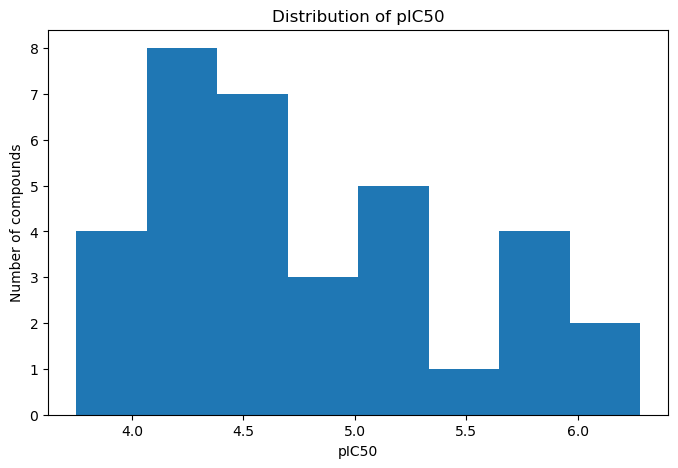

In [42]:
plt.figure(figsize=(8, 5))
plt.hist(df["pIC50"], bins=8)
plt.xlabel("pIC50")
plt.ylabel("Number of compounds")
plt.title("Distribution of pIC50")
plt.show()

In [43]:
df[["ID", "Compound", "pIC50"]].sort_values("pIC50")

,ID,Compound,pIC50
19,20,K20,3.75
13,14,K14,3.85
21,22,K22,4.03
12,13,K13,4.04
20,21,K21,4.10
22,23,K23,4.13
17,18,K18,4.15
14,15,K15,4.18
28,29,K29,4.18
15,16,K16,4.23


In [44]:
from sklearn.model_selection import train_test_split

In [45]:
activity_bins = pd.qcut(
    df["pIC50"],
    q=4,
    labels=False,
    duplicates="drop"
)

In [46]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=activity_bins
)

In [47]:
print("Training compounds:", len(train_df))
print("External test compounds:", len(test_df))

Training compounds: 27
External test compounds: 7


In [48]:
print("\nTraining pIC50 range:")
print(train_df["pIC50"].min(), "to", train_df["pIC50"].max())


Training pIC50 range:
3.85 to 6.28


In [49]:
print("\nTest pIC50 range:")
print(test_df["pIC50"].min(), "to", test_df["pIC50"].max())


Test pIC50 range:
3.75 to 5.88


In [50]:
test_df[["ID", "Compound", "pIC50"]].sort_values("pIC50")

,ID,Compound,pIC50
19,20,K20,3.75
17,18,K18,4.15
31,32,K32,4.37
26,27,K27,4.40
32,33,K33,4.54
9,10,K10,5.31
1,2,K2,5.88


In [51]:
train_df[["ID", "Compound", "pIC50"]].sort_values("pIC50")

,ID,Compound,pIC50
13,14,K14,3.85
21,22,K22,4.03
12,13,K13,4.04
20,21,K21,4.10
22,23,K23,4.13
28,29,K29,4.18
14,15,K15,4.18
15,16,K16,4.23
33,34,K34,4.32
18,19,K19,4.39


In [52]:
X_train = rdkit_desc_clean.loc[train_df.index].copy()
X_test = rdkit_desc_clean.loc[test_df.index].copy()

In [53]:
y_train = train_df["pIC50"].copy()
y_test = test_df["pIC50"].copy()

In [54]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (27, 144)
X_test: (7, 144)
y_train: (27,)
y_test: (7,)


In [55]:
import numpy as np

In [56]:
corr_matrix = X_train.corr().abs()

In [57]:
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [58]:
high_corr = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.90)
]


In [59]:
print("Number of highly correlated descriptors:", len(high_corr))
print("\nDescriptors to remove:")
print(high_corr)

Number of highly correlated descriptors: 69

Descriptors to remove:
['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_LOGPLOW', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'SMR_VSA10', 'SMR_VSA7', 'SlogP_VSA12', 'SlogP_VSA5', 'SlogP_VSA6', 'SlogP_VSA7', 'SlogP_VSA8', 'VSA_EState10', 'VSA_EState6', 'FractionCSP3', 'HeavyAtomCount', 'NHOHCount', 'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumSaturatedRings', 'NumSpiroAtoms', 'Phi', 'RingCount', 'MolLogP', 'MolMR', 'fr_Ar_OH', 'fr_C_O', 'fr_C_O_noCOO', 'fr_NH0', 'fr_benzene', 'fr_bicyclic', 'fr_furan', 'fr_halogen', 'fr_methoxy', 'fr_nitro', 'fr_n

In [60]:
X_train_corr = X_train.drop(columns=high_corr)
X_test_corr = X_test.drop(columns=high_corr)

In [61]:
print("Training descriptors before filtering:", X_train.shape[1])
print("Training descriptors after filtering:", X_train_corr.shape[1])

Training descriptors before filtering: 144
Training descriptors after filtering: 75


In [62]:
print("Test descriptors after filtering:", X_test_corr.shape[1])

Test descriptors after filtering: 75


In [63]:
print("Remaining descriptors:")
print(X_train_corr.columns.tolist())

Remaining descriptors:
['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'MaxPartialCharge', 'MinPartialCharge', 'FpDensityMorgan1', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Ipc', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA11', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4', 'TPSA', 'EState_VSA1', 'EState_VSA10', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState2', 'VSA_EState3', 'VSA_EState4', 'VSA_EState5', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'NumAliphaticHeterocycles', 'NumAtomStereoCenters', 'NumHeterocycles', 'NumSaturate

In [64]:
print("Number of remaining descriptors:", X_train_corr.shape[1])

Number of remaining descriptors: 75


In [65]:
descriptor_activity_corr = X_train_corr.copy()
descriptor_activity_corr["pIC50"] = y_train

In [66]:
corr_with_activity = (
    descriptor_activity_corr
    .corr()["pIC50"]
    .drop("pIC50")
    .sort_values(key=abs, ascending=False)
)

In [67]:
print(corr_with_activity)

FpDensityMorgan1    0.664026
SMR_VSA1           -0.605142
PEOE_VSA12         -0.576112
PEOE_VSA5           0.562678
PEOE_VSA11         -0.555839
                      ...   
NumHeterocycles     0.036328
VSA_EState7         0.030160
MaxPartialCharge   -0.020551
PEOE_VSA10          0.019335
SlogP_VSA10        -0.001463
Name: pIC50, Length: 75, dtype: float64


In [68]:
print("Top 15 positive correlations:")

Top 15 positive correlations:


In [69]:
print(corr_with_activity.sort_values(ascending=False).head(15))

FpDensityMorgan1            0.664026
PEOE_VSA5                   0.562678
NumAliphaticHeterocycles    0.541400
SPS                         0.541329
VSA_EState8                 0.501620
EState_VSA8                 0.472700
MinAbsEStateIndex           0.433843
MinPartialCharge            0.428830
qed                         0.414783
PEOE_VSA8                   0.403105
NumAtomStereoCenters        0.386691
VSA_EState5                 0.371303
fr_Al_OH                    0.348720
fr_allylic_oxid             0.329152
EState_VSA4                 0.324310
Name: pIC50, dtype: float64


In [70]:
print("\nTop 15 negative correlations:")
print(corr_with_activity.sort_values(ascending=True).head(15))


Top 15 negative correlations:
SMR_VSA1            -0.605142
PEOE_VSA12          -0.576112
PEOE_VSA11          -0.555839
BCUT2D_MRHI         -0.550303
PEOE_VSA9           -0.540465
SMR_VSA9            -0.506066
BertzCT             -0.500667
VSA_EState1         -0.500086
MolWt               -0.478406
EState_VSA6         -0.477839
VSA_EState2         -0.449780
fr_ketone           -0.445585
TPSA                -0.432526
MaxAbsEStateIndex   -0.431732
EState_VSA9         -0.430058
Name: pIC50, dtype: float64


In [71]:
candidate_descriptors = corr_with_activity[
    corr_with_activity.abs() >= 0.30
].index.tolist()

In [72]:
print("Number of candidate descriptors:", len(candidate_descriptors))
print("\nCandidate descriptors:")
print(candidate_descriptors)

Number of candidate descriptors: 39

Candidate descriptors:
['FpDensityMorgan1', 'SMR_VSA1', 'PEOE_VSA12', 'PEOE_VSA5', 'PEOE_VSA11', 'BCUT2D_MRHI', 'NumAliphaticHeterocycles', 'SPS', 'PEOE_VSA9', 'SMR_VSA9', 'VSA_EState8', 'BertzCT', 'VSA_EState1', 'MolWt', 'EState_VSA6', 'EState_VSA8', 'VSA_EState2', 'fr_ketone', 'MinAbsEStateIndex', 'TPSA', 'MaxAbsEStateIndex', 'EState_VSA9', 'MinPartialCharge', 'qed', 'PEOE_VSA8', 'NumAtomStereoCenters', 'PEOE_VSA1', 'VSA_EState5', 'fr_Al_OH', 'EState_VSA2', 'AvgIpc', 'fr_allylic_oxid', 'EState_VSA4', 'SlogP_VSA11', 'PEOE_VSA7', 'VSA_EState9', 'SMR_VSA6', 'Ipc', 'PEOE_VSA6']


In [73]:
candidate_corr = corr_with_activity.loc[candidate_descriptors].sort_values(
    key=abs,
    ascending=False
)

print(candidate_corr)

FpDensityMorgan1            0.664026
SMR_VSA1                   -0.605142
PEOE_VSA12                 -0.576112
PEOE_VSA5                   0.562678
PEOE_VSA11                 -0.555839
BCUT2D_MRHI                -0.550303
NumAliphaticHeterocycles    0.541400
SPS                         0.541329
PEOE_VSA9                  -0.540465
SMR_VSA9                   -0.506066
VSA_EState8                 0.501620
BertzCT                    -0.500667
VSA_EState1                -0.500086
MolWt                      -0.478406
EState_VSA6                -0.477839
EState_VSA8                 0.472700
VSA_EState2                -0.449780
fr_ketone                  -0.445585
MinAbsEStateIndex           0.433843
TPSA                       -0.432526
MaxAbsEStateIndex          -0.431732
EState_VSA9                -0.430058
MinPartialCharge            0.428830
qed                         0.414783
PEOE_VSA8                   0.403105
NumAtomStereoCenters        0.386691
PEOE_VSA1                  -0.374848
V

In [74]:
candidate_X = X_train_corr[candidate_descriptors].copy()

In [75]:
candidate_corr_matrix = candidate_X.corr().abs()

In [76]:
upper = candidate_corr_matrix.where(
    np.triu(np.ones(candidate_corr_matrix.shape), k=1).astype(bool)
)

In [77]:
redundant_candidates = [
    column
    for column in upper.columns
    if any(upper[column] > 0.85)
]


In [78]:
print("Number of redundant candidate descriptors:", len(redundant_candidates))
print("\nDescriptors to remove:")
print(redundant_candidates)

Number of redundant candidate descriptors: 7

Descriptors to remove:
['SPS', 'VSA_EState1', 'MaxAbsEStateIndex', 'EState_VSA9', 'qed', 'AvgIpc', 'PEOE_VSA6']


In [79]:
correlated_pairs = []

In [80]:
for i in range(len(candidate_corr_matrix.columns)):
    for j in range(i + 1, len(candidate_corr_matrix.columns)):
        r = candidate_corr_matrix.iloc[i, j]

In [81]:
if r > 0.85:
            correlated_pairs.append({
                "Descriptor_1": candidate_corr_matrix.columns[i],
                "Descriptor_2": candidate_corr_matrix.columns[j],
                "Absolute_r": r
            })

In [82]:
correlated_pairs_df = pd.DataFrame(correlated_pairs)

In [83]:
correlated_pairs = []

for i in range(len(candidate_corr_matrix.columns)):
    for j in range(i + 1, len(candidate_corr_matrix.columns)):
        r = candidate_corr_matrix.iloc[i, j]

        if r > 0.85:
            correlated_pairs.append({
                "Descriptor_1": candidate_corr_matrix.columns[i],
                "Descriptor_2": candidate_corr_matrix.columns[j],
                "Correlation": r
            })

correlated_pairs_df = pd.DataFrame(correlated_pairs)

if len(correlated_pairs_df) > 0:
    correlated_pairs_df = correlated_pairs_df.sort_values(
        "Correlation",
        ascending=False
    ).reset_index(drop=True)

print("Number of correlated pairs:", len(correlated_pairs_df))
display(correlated_pairs_df)

Number of correlated pairs: 7


,Descriptor_1,Descriptor_2,Correlation
0,BertzCT,MaxAbsEStateIndex,0.882977
1,qed,PEOE_VSA6,0.880775
2,NumAliphaticHeterocycles,SPS,0.871357
3,PEOE_VSA9,VSA_EState1,0.860839
4,VSA_EState1,EState_VSA9,0.860774
5,MolWt,qed,0.857658
6,MolWt,AvgIpc,0.854498


In [84]:
remove_redundant = [
    "MaxAbsEStateIndex",
    "PEOE_VSA6",
    "SPS",
    "VSA_EState1",
    "EState_VSA9",
    "qed",
    "AvgIpc"
]

In [85]:
candidate_final = [
    d for d in candidate_descriptors
    if d not in remove_redundant
]


In [86]:
X_candidate = X_train_corr[candidate_final].copy()

In [87]:
print("Descriptors before redundancy filtering:", len(candidate_descriptors))
print("Descriptors removed:", len(remove_redundant))
print("Descriptors remaining:", len(candidate_final))

Descriptors before redundancy filtering: 39
Descriptors removed: 7
Descriptors remaining: 32


In [88]:
print("\nRemaining descriptors:")
print(candidate_final)


Remaining descriptors:
['FpDensityMorgan1', 'SMR_VSA1', 'PEOE_VSA12', 'PEOE_VSA5', 'PEOE_VSA11', 'BCUT2D_MRHI', 'NumAliphaticHeterocycles', 'PEOE_VSA9', 'SMR_VSA9', 'VSA_EState8', 'BertzCT', 'MolWt', 'EState_VSA6', 'EState_VSA8', 'VSA_EState2', 'fr_ketone', 'MinAbsEStateIndex', 'TPSA', 'MinPartialCharge', 'PEOE_VSA8', 'NumAtomStereoCenters', 'PEOE_VSA1', 'VSA_EState5', 'fr_Al_OH', 'EState_VSA2', 'fr_allylic_oxid', 'EState_VSA4', 'SlogP_VSA11', 'PEOE_VSA7', 'VSA_EState9', 'SMR_VSA6', 'Ipc']


In [89]:
df.to_excel("LPS_NO_QSAR_working_data.xlsx", index=False)

In [90]:
rdkit_desc.to_excel("LPS_NO_QSAR_RDKit_descriptors.xlsx", index=False)

In [91]:
print("Working files saved successfully.")

Working files saved successfully.


In [92]:
print("Compounds:", len(df))
print("Training compounds:", len(train_df))
print("Test compounds:", len(test_df))
print("Candidate descriptors:", len(candidate_final))
print("X_candidate shape:", X_candidate.shape)

Compounds: 34
Training compounds: 27
Test compounds: 7
Candidate descriptors: 32
X_candidate shape: (27, 32)


In [93]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

In [94]:
scaler = StandardScaler()

In [95]:
X_candidate_scaled = scaler.fit_transform(X_candidate)

In [96]:
lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=100000
)

In [97]:
lasso.fit(X_candidate_scaled, y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,100000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [98]:
print("Best alpha:", lasso.alpha_)
print("Training R²:", lasso.score(X_candidate_scaled, y_train))

Best alpha: 0.05872678006489232
Training R²: 0.7638651729095758


In [99]:
lasso_coefficients = pd.Series(
    lasso.coef_,
    index=candidate_final
)

In [100]:
selected_lasso = lasso_coefficients[
    lasso_coefficients != 0
].sort_values(key=abs, ascending=False)

In [101]:
print("Number of descriptors selected by LASSO:",
      len(selected_lasso))

Number of descriptors selected by LASSO: 9


In [102]:
print("\nSelected descriptors:")
print(selected_lasso)


Selected descriptors:
PEOE_VSA5                   0.208556
SMR_VSA1                   -0.177611
NumAliphaticHeterocycles    0.107934
PEOE_VSA12                 -0.094673
EState_VSA6                -0.066141
PEOE_VSA7                  -0.062187
FpDensityMorgan1            0.060542
VSA_EState9                -0.028203
EState_VSA8                 0.004548
dtype: float64


In [103]:
from sklearn.linear_model import ElasticNetCV

In [104]:
elastic = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    cv=5,
    random_state=42,
    max_iter=100000
)

In [105]:
elastic.fit(X_candidate_scaled, y_train)

,l1_ratio,"[0.1, 0.3, ...]"
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,100000
,tol,0.0001
,cv,5
,copy_X,True
,verbose,0


In [106]:
print("Best alpha:", elastic.alpha_)
print("Best l1_ratio:", elastic.l1_ratio_)
print("Training R²:", elastic.score(X_candidate_scaled, y_train))

Best alpha: 0.2062009847409198
Best l1_ratio: 0.1
Training R²: 0.8195408879018631


In [107]:
elastic_coefficients = pd.Series(
    elastic.coef_,
    index=candidate_final
)

In [108]:
selected_elastic = elastic_coefficients[
    elastic_coefficients != 0
].sort_values(key=abs, ascending=False)

In [109]:
print("Number of descriptors selected by Elastic Net:",
      len(selected_elastic))

print("\nSelected descriptors:")
print(selected_elastic)

Number of descriptors selected by Elastic Net: 20

Selected descriptors:
PEOE_VSA5                   0.157465
SMR_VSA1                   -0.118578
NumAliphaticHeterocycles    0.115356
PEOE_VSA7                  -0.099619
PEOE_VSA12                 -0.084064
FpDensityMorgan1            0.080576
VSA_EState5                 0.068519
VSA_EState9                -0.066281
EState_VSA2                 0.065561
EState_VSA6                -0.060451
MinAbsEStateIndex           0.050363
TPSA                        0.047300
EState_VSA8                 0.043065
fr_allylic_oxid             0.038709
EState_VSA4                 0.029841
PEOE_VSA1                  -0.023609
PEOE_VSA11                 -0.020711
SMR_VSA6                   -0.019640
fr_Al_OH                    0.007372
VSA_EState2                -0.003137
dtype: float64


In [110]:
print("Elastic Net best alpha:", elastic.alpha_)
print("Elastic Net best l1_ratio:", elastic.l1_ratio_)
print("Elastic Net training R²:", elastic.score(X_candidate_scaled, y_train))

Elastic Net best alpha: 0.2062009847409198
Elastic Net best l1_ratio: 0.1
Elastic Net training R²: 0.8195408879018631


In [111]:
print("LASSO best alpha:", lasso.alpha_)
print("LASSO training R²:", lasso.score(X_candidate_scaled, y_train))

LASSO best alpha: 0.05872678006489232
LASSO training R²: 0.7638651729095758


In [112]:
from sklearn.model_selection import KFold, cross_val_predict

In [113]:
from sklearn.pipeline import Pipeline

In [114]:
from sklearn.preprocessing import StandardScaler

In [115]:
from sklearn.linear_model import Lasso, ElasticNet

In [116]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [117]:
import numpy as np

In [118]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [119]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(
        alpha=lasso.alpha_,
        max_iter=100000
    ))
])

In [120]:
elastic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=elastic.alpha_,
        l1_ratio=elastic.l1_ratio_,
        max_iter=100000
    ))
])

In [121]:
lasso_pred_cv = cross_val_predict(
    lasso_model,
    X_candidate,
    y_train,
    cv=cv
)

elastic_pred_cv = cross_val_predict(
    elastic_model,
    X_candidate,
    y_train,
    cv=cv
)

In [122]:
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

In [123]:
lasso_metrics = calculate_metrics(y_train, lasso_pred_cv)
elastic_metrics = calculate_metrics(y_train, elastic_pred_cv)

In [124]:
print("LASSO CV")
print("R² / Q²:", lasso_metrics[0])
print("RMSE:", lasso_metrics[1])
print("MAE:", lasso_metrics[2])

LASSO CV
R² / Q²: 0.12077172202951425
RMSE: 0.62732068363773
MAE: 0.49558569516090145


In [125]:
print("\nElastic Net CV")
print("R² / Q²:", elastic_metrics[0])
print("RMSE:", elastic_metrics[1])
print("MAE:", elastic_metrics[2])


Elastic Net CV
R² / Q²: 0.20922746347574694
RMSE: 0.5949282232588669
MAE: 0.45725113826123226


In [126]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

max_components = min(8, X_candidate.shape[1], len(X_candidate) - 1)

pls_results = []

for n_comp in range(1, max_components + 1):

    pls_model = Pipeline([
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(n_components=n_comp))
    ])

    y_pred = cross_val_predict(
        pls_model,
        X_candidate,
        y_train,
        cv=cv
    ).ravel()

    r2 = r2_score(y_train, y_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    mae = mean_absolute_error(y_train, y_pred)

    pls_results.append({
        "Components": n_comp,
        "CV_R2_Q2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

pls_results_df = pd.DataFrame(pls_results)

print(pls_results_df)

   Components  CV_R2_Q2      RMSE       MAE
0           1  0.372989  0.529757  0.397692
1           2  0.344634  0.541603  0.412455
2           3  0.108532  0.631672  0.500204
3           4 -0.116076  0.706782  0.554096
4           5 -0.510626  0.822275  0.628894
5           6 -0.640362  0.856858  0.668621
6           7 -1.479521  1.053471  0.776062
7           8 -2.309305  1.217047  0.855204


In [127]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42
)

rf_pred_cv = cross_val_predict(
    rf,
    X_candidate,
    y_train,
    cv=cv
)

rf_r2 = r2_score(y_train, rf_pred_cv)
rf_rmse = np.sqrt(mean_squared_error(y_train, rf_pred_cv))
rf_mae = mean_absolute_error(y_train, rf_pred_cv)

print("Random Forest CV")
print("R² / Q²:", rf_r2)
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)

Random Forest CV
R² / Q²: 0.31404729182664193
RMSE: 0.5540970918948732
MAE: 0.42259031951793075


In [128]:
from sklearn.svm import SVR

svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        gamma="scale",
        epsilon=0.1
    ))
])

svr_pred_cv = cross_val_predict(
    svr_model,
    X_candidate,
    y_train,
    cv=cv
)

svr_r2 = r2_score(y_train, svr_pred_cv)
svr_rmse = np.sqrt(mean_squared_error(y_train, svr_pred_cv))
svr_mae = mean_absolute_error(y_train, svr_pred_cv)

print("SVR CV")
print("R² / Q²:", svr_r2)
print("RMSE:", svr_rmse)
print("MAE:", svr_mae)

SVR CV
R² / Q²: 0.24448649775329845
RMSE: 0.5815136298751391
MAE: 0.4743790084139488


In [129]:
pls_cv_table = pd.DataFrame({
    "ID": train_df["ID"].values,
    "Compound": train_df["Compound"].values,
    "Observed_pIC50": y_train.values,
    "Predicted_pIC50": pls_results_df.iloc[0:0]["CV_R2_Q2"] if False else y_train.values
})

In [130]:
pls_1_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pls", PLSRegression(n_components=1))
])

pls_1_pred_cv = cross_val_predict(
    pls_1_model,
    X_candidate,
    y_train,
    cv=cv
).ravel()

pls_cv_table = pd.DataFrame({
    "ID": train_df["ID"].values,
    "Compound": train_df["Compound"].values,
    "Observed_pIC50": y_train.values,
    "Predicted_pIC50": pls_1_pred_cv
})

pls_cv_table["Residual"] = (
    pls_cv_table["Observed_pIC50"] -
    pls_cv_table["Predicted_pIC50"]
)

print(pls_cv_table.sort_values("Observed_pIC50"))

    ID Compound  Observed_pIC50  Predicted_pIC50  Residual
10  14      K14            3.85         3.989371 -0.139371
14  22      K22            4.03         4.839695 -0.809695
9   13      K13            4.04         3.911483  0.128517
17  21      K21            4.10         4.099023  0.000977
16  23      K23            4.13         4.577108 -0.447108
3   29      K29            4.18         5.030949 -0.850949
6   15      K15            4.18         3.540652  0.639348
23  16      K16            4.23         4.528723 -0.298723
8   34      K34            4.32         4.568153 -0.248153
12  19      K19            4.39         4.242973  0.147027
26  31      K31            4.41         5.049647 -0.639647
5   28      K28            4.43         4.808666 -0.378666
1   30      K30            4.48         4.801345 -0.321345
21  26      K26            4.58         4.428569  0.151431
15  24      K24            4.70         4.951299 -0.251299
19  25      K25            4.85         4.863760 -0.0137

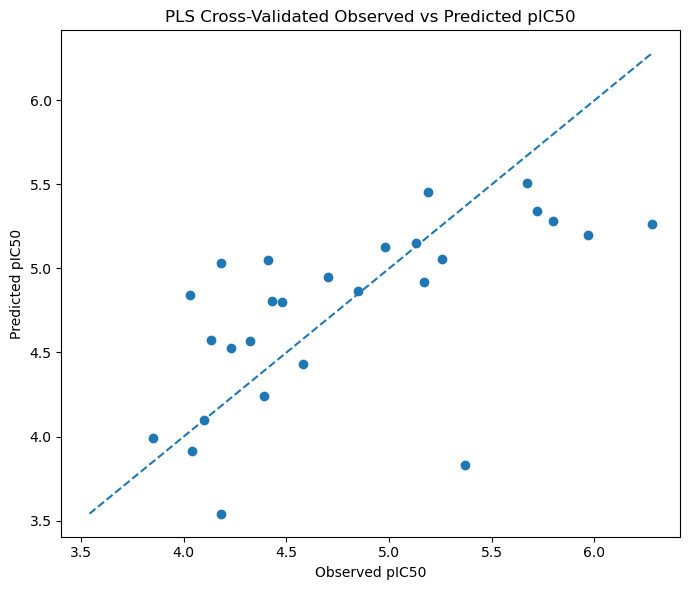

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    pls_cv_table["Observed_pIC50"],
    pls_cv_table["Predicted_pIC50"]
)

# Ideal prediction line
min_val = min(
    pls_cv_table["Observed_pIC50"].min(),
    pls_cv_table["Predicted_pIC50"].min()
)

max_val = max(
    pls_cv_table["Observed_pIC50"].max(),
    pls_cv_table["Predicted_pIC50"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed pIC50")
plt.ylabel("Predicted pIC50")
plt.title("PLS Cross-Validated Observed vs Predicted pIC50")

plt.tight_layout()
plt.show()

In [132]:
print("Maximum absolute residual:",
      np.max(np.abs(pls_cv_table["Residual"])))

print("Mean absolute residual:",
      np.mean(np.abs(pls_cv_table["Residual"])))

print("\nLargest prediction errors:")

print(
    pls_cv_table
    .assign(Absolute_Error=lambda x: np.abs(x["Residual"]))
    .sort_values("Absolute_Error", ascending=False)
    [["ID", "Compound", "Observed_pIC50",
      "Predicted_pIC50", "Residual", "Absolute_Error"]]
    .head(10)
)

Maximum absolute residual: 1.5412699941108947
Mean absolute residual: 0.39769170357892425

Largest prediction errors:
    ID Compound  Observed_pIC50  Predicted_pIC50  Residual  Absolute_Error
0   17      K17            5.37         3.828730  1.541270        1.541270
25   1       K1            6.28         5.261764  1.018236        1.018236
3   29      K29            4.18         5.030949 -0.850949        0.850949
14  22      K22            4.03         4.839695 -0.809695        0.809695
20   3       K3            5.97         5.198129  0.771871        0.771871
26  31      K31            4.41         5.049647 -0.639647        0.639647
6   15      K15            4.18         3.540652  0.639348        0.639348
7    9       K9            5.80         5.283371  0.516629        0.516629
16  23      K23            4.13         4.577108 -0.447108        0.447108
5   28      K28            4.43         4.808666 -0.378666        0.378666


In [133]:
X_test_candidate = X_test_corr[candidate_final].copy()

print("Training matrix:", X_candidate.shape)
print("External test matrix:", X_test_candidate.shape)

Training matrix: (27, 32)
External test matrix: (7, 32)


In [134]:
final_pls = Pipeline([
    ("scaler", StandardScaler()),
    ("pls", PLSRegression(n_components=1))
])

final_pls.fit(X_candidate, y_train)

# Predict the untouched external test set
y_test_pred = final_pls.predict(X_test_candidate).ravel()

# External validation metrics
external_r2 = r2_score(y_test, y_test_pred)
external_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
external_mae = mean_absolute_error(y_test, y_test_pred)

print("External Test R²:", external_r2)
print("External Test RMSE:", external_rmse)
print("External Test MAE:", external_mae)

External Test R²: 0.22029455873932857
External Test RMSE: 0.5931191829742649
External Test MAE: 0.460207498221469


In [135]:
external_results = pd.DataFrame({
    "ID": test_df["ID"].values,
    "Compound": test_df["Compound"].values,
    "Observed_pIC50": y_test.values,
    "Predicted_pIC50": y_test_pred
})

external_results["Residual"] = (
    external_results["Observed_pIC50"] -
    external_results["Predicted_pIC50"]
)

external_results["Absolute_Error"] = (
    external_results["Residual"].abs()
)

print(external_results.sort_values("Observed_pIC50"))

   ID Compound  Observed_pIC50  Predicted_pIC50  Residual  Absolute_Error
0  20      K20            3.75         4.056396 -0.306396        0.306396
6  18      K18            4.15         3.050303  1.099697        1.099697
3  32      K32            4.37         4.497728 -0.127728        0.127728
5  27      K27            4.40         5.249494 -0.849494        0.849494
2  33      K33            4.54         4.508238  0.031762        0.031762
4  10      K10            5.31         5.125028  0.184972        0.184972
1   2       K2            5.88         5.258596  0.621404        0.621404


In [136]:
external_results.to_excel(
    "PLS_external_validation_results.xlsx",
    index=False
)

print("External validation results saved.")

External validation results saved.


In [137]:
model_comparison = pd.DataFrame({
    "Model": [
        "LASSO",
        "Elastic Net",
        "PLS_1_component",
        "Random Forest",
        "SVR"
    ],
    "CV_R2_Q2": [
        lasso_metrics[0],
        elastic_metrics[0],
        pls_results_df.loc[0, "CV_R2_Q2"],
        rf_r2,
        svr_r2
    ],
    "CV_RMSE": [
        lasso_metrics[1],
        elastic_metrics[1],
        pls_results_df.loc[0, "RMSE"],
        rf_rmse,
        svr_rmse
    ],
    "CV_MAE": [
        lasso_metrics[2],
        elastic_metrics[2],
        pls_results_df.loc[0, "MAE"],
        rf_mae,
        svr_mae
    ]
})

print(model_comparison)

             Model  CV_R2_Q2   CV_RMSE    CV_MAE
0            LASSO  0.120772  0.627321  0.495586
1      Elastic Net  0.209227  0.594928  0.457251
2  PLS_1_component  0.372989  0.529757  0.397692
3    Random Forest  0.314047  0.554097  0.422590
4              SVR  0.244486  0.581514  0.474379


In [138]:
print("Number of molecules:", df["Mol"].notna().sum())
print("Total compounds:", len(df))

Number of molecules: 34
Total compounds: 34


In [139]:
from rdkit.Chem import rdFingerprintGenerator

In [140]:
# Morgan fingerprint generator
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

# Generate fingerprints
morgan_fps = [
    morgan_generator.GetFingerprint(mol)
    for mol in df["Mol"]
]

print("Number of fingerprints:", len(morgan_fps))
print("Fingerprint size:", morgan_fps[0].GetNumBits())

Number of fingerprints: 34
Fingerprint size: 2048


In [141]:
from rdkit import DataStructs
import numpy as np
import pandas as pd

# Calculate pairwise Tanimoto similarity
n = len(morgan_fps)

similarity_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        similarity_matrix[i, j] = DataStructs.TanimotoSimilarity(
            morgan_fps[i],
            morgan_fps[j]
        )

# Convert to DataFrame
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df["Compound"],
    columns=df["Compound"]
)

print("Similarity matrix shape:", similarity_df.shape)
print(similarity_df.round(3).head())

Similarity matrix shape: (34, 34)
Compound     K1     K2     K3     K4     K5     K6     K7     K8     K9  \
Compound                                                                  
K1        1.000  0.361  0.412  0.324  0.175  0.184  0.247  0.224  0.192   
K2        0.361  1.000  0.492  0.242  0.323  0.367  0.186  0.181  0.164   
K3        0.412  0.492  1.000  0.176  0.217  0.231  0.266  0.239  0.221   
K4        0.324  0.242  0.176  1.000  0.300  0.370  0.271  0.242  0.262   
K5        0.175  0.323  0.217  0.300  1.000  0.472  0.317  0.306  0.227   

Compound    K10  ...    K25    K26    K27    K28    K29    K30    K31    K32  \
Compound         ...                                                           
K1        0.141  ...  0.140  0.137  0.145  0.160  0.207  0.268  0.188  0.136   
K2        0.286  ...  0.195  0.163  0.160  0.137  0.230  0.139  0.162  0.136   
K3        0.274  ...  0.143  0.114  0.133  0.116  0.171  0.143  0.152  0.111   
K4        0.197  ...  0.200  0.211  0.29

In [142]:
# Remove self-similarity from consideration
similarity_no_self = similarity_matrix.copy()
np.fill_diagonal(similarity_no_self, np.nan)

# Find highest pairwise similarity
max_index = np.unravel_index(
    np.nanargmax(similarity_no_self),
    similarity_no_self.shape
)

i, j = max_index

print("Most similar pair:")
print(df.iloc[i]["Compound"], "vs", df.iloc[j]["Compound"])
print("Tanimoto similarity:",
      similarity_no_self[i, j])

Most similar pair:
K23 vs K26
Tanimoto similarity: 0.7931034482758621


In [143]:
# Extract unique pairwise similarities
upper_values = similarity_matrix[
    np.triu_indices(n, k=1)
]

print("Number of unique compound pairs:", len(upper_values))
print("Mean Tanimoto similarity:", np.mean(upper_values))
print("Median Tanimoto similarity:", np.median(upper_values))
print("Minimum Tanimoto similarity:", np.min(upper_values))
print("Maximum Tanimoto similarity:", np.max(upper_values))

Number of unique compound pairs: 561
Mean Tanimoto similarity: 0.23041538218515514
Median Tanimoto similarity: 0.1780821917808219
Minimum Tanimoto similarity: 0.0970873786407767
Maximum Tanimoto similarity: 0.7931034482758621


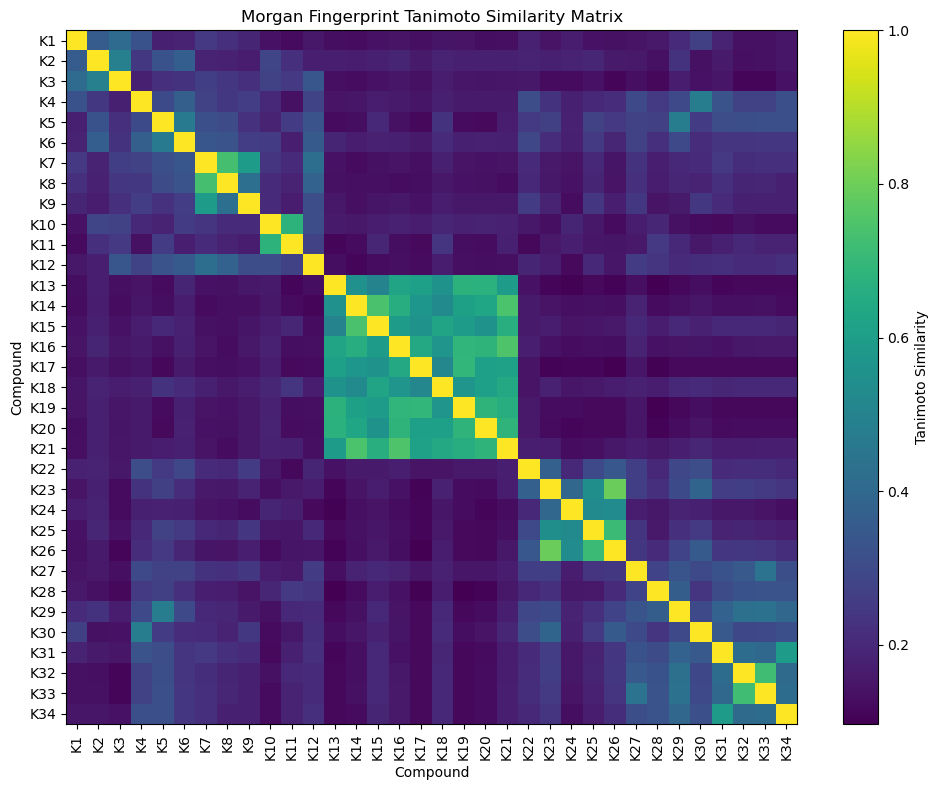

In [197]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(
    similarity_matrix,
    aspect="auto"
)

plt.colorbar(label="Tanimoto Similarity")

plt.xticks(
    range(len(df)),
    df["Compound"],
    rotation=90
)

plt.yticks(
    range(len(df)),
    df["Compound"]
)

plt.xlabel("Compound")
plt.ylabel("Compound")
plt.title("Morgan Fingerprint Tanimoto Similarity Matrix")

plt.tight_layout()
plt.savefig(
    "Figure_Morgan_Tanimoto_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [145]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Convert Morgan fingerprints to NumPy array
fp_array = np.array([
    list(fp)
    for fp in morgan_fps
])

print("Fingerprint matrix shape:", fp_array.shape)

# PCA
pca = PCA(n_components=2)

fp_pca = pca.fit_transform(fp_array)

print("PC1 explained variance:",
      pca.explained_variance_ratio_[0])

print("PC2 explained variance:",
      pca.explained_variance_ratio_[1])

print("Total explained variance:",
      pca.explained_variance_ratio_.sum())

Fingerprint matrix shape: (34, 2048)
PC1 explained variance: 0.23508572349917897
PC2 explained variance: 0.10835400722836727
Total explained variance: 0.34343973072754624


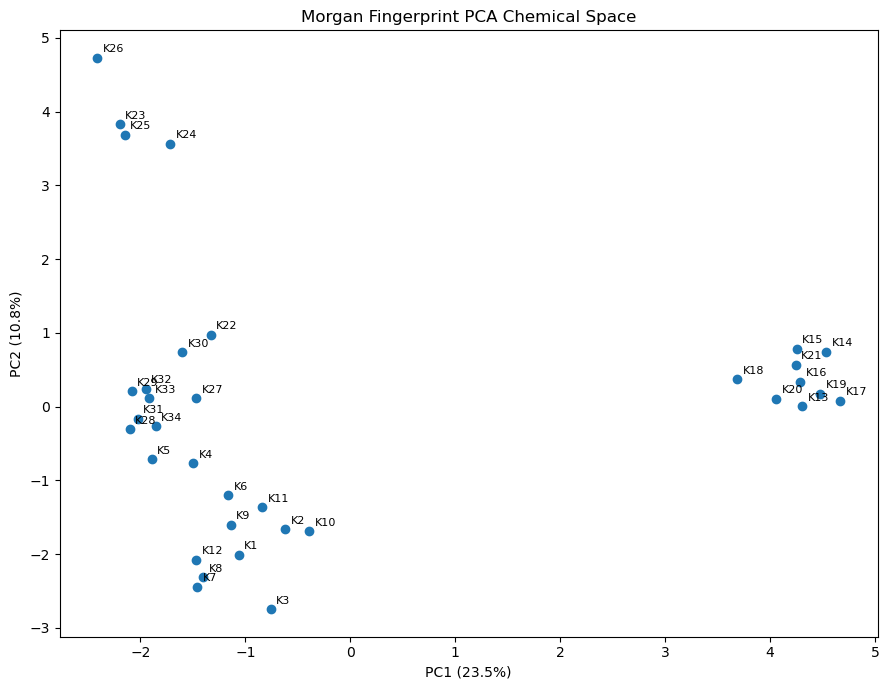

In [196]:
plt.figure(figsize=(9, 7))

plt.scatter(
    fp_pca[:, 0],
    fp_pca[:, 1]
)

# Label each compound
for i, compound in enumerate(df["Compound"]):
    plt.annotate(
        compound,
        (fp_pca[i, 0], fp_pca[i, 1]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title("Morgan Fingerprint PCA Chemical Space")

plt.tight_layout()
plt.savefig(
    "Figure_Morgan_PCA_Chemical_Space.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [147]:
# Training and external-test indices
train_indices = train_df.index
test_indices = test_df.index

train_fps = [morgan_fps[i] for i in train_indices]
test_fps = [morgan_fps[i] for i in test_indices]

# Calculate maximum and mean similarity to training compounds
test_similarity_results = []

for idx, fp in zip(test_indices, test_fps):

    similarities = [
        DataStructs.TanimotoSimilarity(fp, train_fp)
        for train_fp in train_fps
    ]

    test_similarity_results.append({
        "ID": df.loc[idx, "ID"],
        "Compound": df.loc[idx, "Compound"],
        "Max_Tanimoto_to_Training": max(similarities),
        "Mean_Tanimoto_to_Training": np.mean(similarities)
    })

test_similarity_df = pd.DataFrame(test_similarity_results)

print(test_similarity_df.sort_values(
    "Max_Tanimoto_to_Training",
    ascending=False
))

   ID Compound  Max_Tanimoto_to_Training  Mean_Tanimoto_to_Training
0  20      K20                  0.685185                   0.267247
4  10      K10                  0.681818                   0.197772
6  18      K18                  0.640625                   0.281631
1   2       K2                  0.491525                   0.209185
2  33      K33                  0.437500                   0.221817
3  32      K32                  0.430769                   0.222351
5  27      K27                  0.333333                   0.226967


In [148]:
# Nearest-neighbor similarity for each training compound

train_similarity_matrix = similarity_matrix[
    np.ix_(train_indices, train_indices)
]

# Remove self-similarity
train_similarity_no_self = train_similarity_matrix.copy()
np.fill_diagonal(train_similarity_no_self, np.nan)

train_max_similarity = np.nanmax(
    train_similarity_no_self,
    axis=1
)

training_nn_df = pd.DataFrame({
    "ID": train_df["ID"].values,
    "Compound": train_df["Compound"].values,
    "Nearest_Neighbor_Tanimoto": train_max_similarity
})

print(training_nn_df.describe())

print("\nTraining compounds with lowest nearest-neighbor similarity:")
print(
    training_nn_df
    .sort_values("Nearest_Neighbor_Tanimoto")
    .head(10)
)

              ID  Nearest_Neighbor_Tanimoto
count  27.000000                  27.000000
mean   16.777778                   0.584213
std     9.637001                   0.154677
min     1.000000                   0.275862
25%     8.500000                   0.473137
50%    16.000000                   0.593220
75%    24.500000                   0.733333
max    34.000000                   0.793103

Training compounds with lowest nearest-neighbor similarity:
    ID Compound  Nearest_Neighbor_Tanimoto
4   11      K11                   0.275862
5   28      K28                   0.362500
14  22      K22                   0.375000
20   3       K3                   0.411765
25   1       K1                   0.411765
22  12      K12                   0.423077
24   6       K6                   0.471698
3   29      K29                   0.474576
2    5       K5                   0.474576
1   30      K30                   0.480000


In [149]:
print("Training nearest-neighbor similarity:")
print("Minimum:", np.min(train_max_similarity))
print("25th percentile:", np.percentile(train_max_similarity, 25))
print("Median:", np.median(train_max_similarity))
print("75th percentile:", np.percentile(train_max_similarity, 75))
print("Maximum:", np.max(train_max_similarity))

Training nearest-neighbor similarity:
Minimum: 0.27586206896551724
25th percentile: 0.4731371921969939
Median: 0.5932203389830508
75th percentile: 0.7333333333333333
Maximum: 0.7931034482758621


In [150]:
import numpy as np
import pandas as pd

# Fit the final 1-component PLS model on the 27 training compounds
pls_ad = PLSRegression(n_components=1)

pls_ad.fit(X_candidate, y_train)

# Obtain PLS latent scores
T_train = pls_ad.x_scores_

# Transform external compounds into the same PLS space
T_test = pls_ad.transform(X_test_candidate)

# Calculate inverse of T'T
TtT_inv = np.linalg.pinv(T_train.T @ T_train)

# Training leverage
train_leverage = np.diag(
    T_train @ TtT_inv @ T_train.T
)

# External-test leverage
test_leverage = np.diag(
    T_test @ TtT_inv @ T_test.T
)

# Critical leverage
n_train = len(y_train)
n_components = 1

h_star = 3 * (n_components + 1) / n_train

print("Number of training compounds:", n_train)
print("Number of PLS components:", n_components)
print("Critical leverage h*:", h_star)

print("\nTraining leverage:")
print("Minimum:", train_leverage.min())
print("Median:", np.median(train_leverage))
print("Maximum:", train_leverage.max())

print("\nExternal test leverage:")
print("Minimum:", test_leverage.min())
print("Maximum:", test_leverage.max())

Number of training compounds: 27
Number of PLS components: 1
Critical leverage h*: 0.2222222222222222

Training leverage:
Minimum: 3.726097545551422e-05
Median: 0.017377553482012243
Maximum: 0.15440099434456153

External test leverage:
Minimum: 0.011560992193620376
Maximum: 0.43026877980949374


In [151]:
train_leverage_df = pd.DataFrame({
    "ID": train_df["ID"].values,
    "Compound": train_df["Compound"].values,
    "Leverage": train_leverage
})

test_leverage_df = pd.DataFrame({
    "ID": test_df["ID"].values,
    "Compound": test_df["Compound"].values,
    "Leverage": test_leverage
})

print("Training leverage:")
print(
    train_leverage_df
    .sort_values("Leverage", ascending=False)
)

print("\nExternal test leverage:")
print(
    test_leverage_df
    .sort_values("Leverage", ascending=False)
)

Training leverage:
    ID Compound  Leverage
6   15      K15  0.154401
25   1       K1  0.104509
13   7       K7  0.078997
10  14      K14  0.078657
17  21      K21  0.074039
20   3       K3  0.070438
0   17      K17  0.069856
9   13      K13  0.062277
11   8       K8  0.051892
12  19      K19  0.045031
22  12      K12  0.041964
7    9       K9  0.037806
18   4       K4  0.035218
23  16      K16  0.017378
26  31      K31  0.013519
4   11      K11  0.012526
21  26      K26  0.011467
16  23      K23  0.010646
2    5       K5  0.010489
5   28      K28  0.008858
3   29      K29  0.002984
24   6       K6  0.002624
8   34      K34  0.001954
15  24      K24  0.001030
19  25      K25  0.000835
1   30      K30  0.000570
14  22      K22  0.000037

External test leverage:
   ID Compound  Leverage
6  18      K18  0.430269
0  20      K20  0.077001
1   2       K2  0.030533
5  27      K27  0.029348
4  10      K10  0.015499
3  32      K32  0.012427
2  33      K33  0.011561


In [152]:
# Predictions from the fitted PLS model
y_train_fitted = pls_ad.predict(X_candidate).ravel()
y_test_fitted = pls_ad.predict(X_test_candidate).ravel()

# Residuals
train_residuals = y_train - y_train_fitted
test_residuals = y_test - y_test_fitted

# Residual standard deviation
n = len(y_train)
p = 1  # one PLS latent component

residual_std = np.sqrt(
    np.sum(train_residuals**2) / (n - p - 1)
)

print("Residual standard deviation:", residual_std)

# Standardized residuals
train_std_residuals = train_residuals / residual_std
test_std_residuals = test_residuals / residual_std

print("\nExternal standardized residuals:")

for compound, value in zip(
    test_df["Compound"],
    test_std_residuals
):
    print(compound, ":", value)

Residual standard deviation: 0.44800822711660365

External standardized residuals:
K20 : -0.68390657236541
K2 : 1.3870367259546017
K33 : 0.07089622128254838
K32 : -0.28510254784209954
K10 : 0.4128752664014959
K27 : -1.8961564242693298
K18 : 2.454636352514987


In [153]:
train_williams = pd.DataFrame({
    "ID": train_df["ID"].values,
    "Compound": train_df["Compound"].values,
    "Leverage": train_leverage,
    "Standardized_Residual": train_std_residuals,
    "Set": "Training"
})

test_williams = pd.DataFrame({
    "ID": test_df["ID"].values,
    "Compound": test_df["Compound"].values,
    "Leverage": test_leverage,
    "Standardized_Residual": test_std_residuals,
    "Set": "External"
})

williams_df = pd.concat(
    [train_williams, test_williams],
    ignore_index=True
)

print(williams_df.sort_values(
    "Leverage",
    ascending=False
))

    ID Compound  Leverage  Standardized_Residual       Set
33  18      K18  0.430269               2.454636  External
6   15      K15  0.154401               0.960949  Training
25   1       K1  0.104509               1.398465  Training
13   7       K7  0.078997               0.287379  Training
10  14      K14  0.078657              -0.443085  Training
27  20      K20  0.077001              -0.683907  External
17  21      K21  0.074039               0.065355  Training
20   3       K3  0.070438               1.049943  Training
0   17      K17  0.069856               2.853843  Training
9   13      K13  0.062277              -0.202370  Training
11   8       K8  0.051892               0.715044  Training
12  19      K19  0.045031               0.357253  Training
22  12      K12  0.041964              -0.331803  Training
7    9       K9  0.037806               1.091576  Training
18   4       K4  0.035218              -0.073571  Training
28   2       K2  0.030533               1.387037  Extern

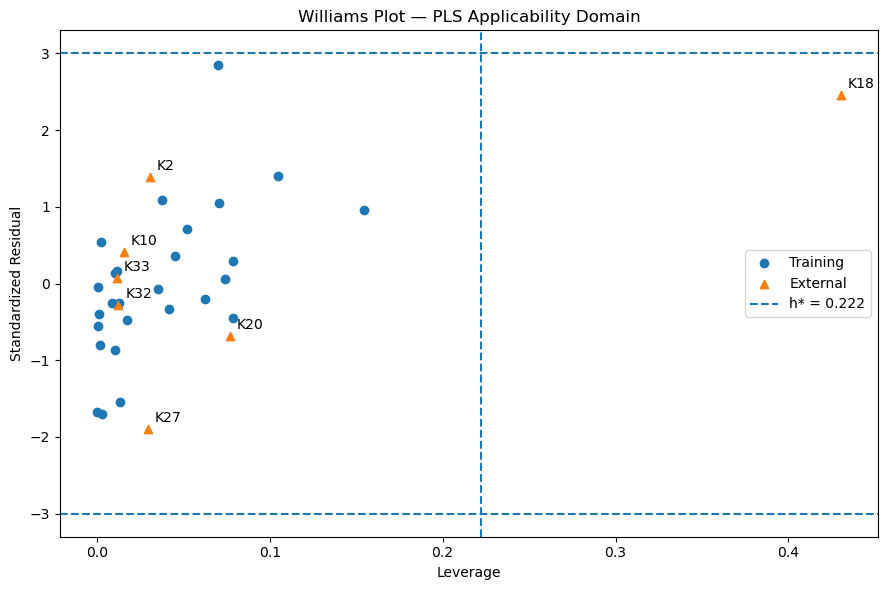

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# Training compounds
training_mask = williams_df["Set"] == "Training"

plt.scatter(
    williams_df.loc[training_mask, "Leverage"],
    williams_df.loc[training_mask, "Standardized_Residual"],
    label="Training"
)

# External compounds
external_mask = williams_df["Set"] == "External"

plt.scatter(
    williams_df.loc[external_mask, "Leverage"],
    williams_df.loc[external_mask, "Standardized_Residual"],
    marker="^",
    label="External"
)

# Label external compounds
for _, row in williams_df[external_mask].iterrows():
    plt.annotate(
        row["Compound"],
        (row["Leverage"], row["Standardized_Residual"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Critical leverage
plt.axvline(
    h_star,
    linestyle="--",
    label=f"h* = {h_star:.3f}"
)

# Residual boundaries
plt.axhline(3, linestyle="--")
plt.axhline(-3, linestyle="--")

plt.xlabel("Leverage")
plt.ylabel("Standardized Residual")
plt.title("Williams Plot — PLS Applicability Domain")
plt.legend()

plt.tight_layout()
plt.savefig(
    "Figure_PLS_Williams_Applicability_Domain.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [155]:
# Convert Morgan fingerprints to NumPy matrix
X_morgan = np.array([
    list(fp)
    for fp in morgan_fps
])

print("Morgan fingerprint matrix:", X_morgan.shape)

Morgan fingerprint matrix: (34, 2048)


In [156]:
X_morgan_train = X_morgan[train_df.index]
X_morgan_test = X_morgan[test_df.index]

print("Morgan training:", X_morgan_train.shape)
print("Morgan test:", X_morgan_test.shape)

Morgan training: (27, 2048)
Morgan test: (7, 2048)


In [157]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Random Forest model
rf_morgan = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_features="sqrt",
    min_samples_leaf=1,
    n_jobs=-1
)

# 5-fold cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validated predictions
y_rf_cv = cross_val_predict(
    rf_morgan,
    X_morgan_train,
    y_train,
    cv=kf
)

# CV metrics
rf_morgan_r2 = r2_score(y_train, y_rf_cv)
rf_morgan_rmse = np.sqrt(
    mean_squared_error(y_train, y_rf_cv)
)
rf_morgan_mae = mean_absolute_error(
    y_train, y_rf_cv
)

print("Morgan Random Forest CV")
print("R² / Q²:", rf_morgan_r2)
print("RMSE:", rf_morgan_rmse)
print("MAE:", rf_morgan_mae)

Morgan Random Forest CV
R² / Q²: 0.4377745239151687
RMSE: 0.5016421768043087
MAE: 0.3826506172839426


In [158]:
# Fit Morgan Random Forest on the complete training set
rf_morgan.fit(
    X_morgan_train,
    y_train
)

# Predict the 7 external compounds
y_rf_external = rf_morgan.predict(
    X_morgan_test
)

# External validation metrics
rf_external_r2 = r2_score(
    y_test,
    y_rf_external
)

rf_external_rmse = np.sqrt(
    mean_squared_error(y_test, y_rf_external)
)

rf_external_mae = mean_absolute_error(
    y_test,
    y_rf_external
)

print("Morgan Random Forest External Validation")
print("R²:", rf_external_r2)
print("RMSE:", rf_external_rmse)
print("MAE:", rf_external_mae)

Morgan Random Forest External Validation
R²: 0.748895216410358
RMSE: 0.33659230336671436
MAE: 0.281671428571424


In [159]:
rf_external_results = pd.DataFrame({
    "ID": test_df["ID"].values,
    "Compound": test_df["Compound"].values,
    "Observed_pIC50": y_test.values,
    "Predicted_pIC50": y_rf_external,
    "Residual": y_test.values - y_rf_external,
    "Absolute_Error": np.abs(
        y_test.values - y_rf_external
    )
})

print(
    rf_external_results.sort_values(
        "Observed_pIC50"
    )
)

   ID Compound  Observed_pIC50  Predicted_pIC50  Residual  Absolute_Error
0  20      K20            3.75          4.30726  -0.55726         0.55726
6  18      K18            4.15          4.34458  -0.19458         0.19458
3  32      K32            4.37          4.45284  -0.08284         0.08284
5  27      K27            4.40          4.61922  -0.21922         0.21922
2  33      K33            4.54          4.44872   0.09128         0.09128
4  10      K10            5.31          5.03788   0.27212         0.27212
1   2       K2            5.88          5.32560   0.55440         0.55440


In [160]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Morgan fingerprint SVR pipeline
svr_morgan = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        gamma="scale",
        epsilon=0.1
    ))
])

# 5-fold cross-validation
y_svr_morgan_cv = cross_val_predict(
    svr_morgan,
    X_morgan_train,
    y_train,
    cv=kf
)

# CV metrics
svr_morgan_r2 = r2_score(
    y_train,
    y_svr_morgan_cv
)

svr_morgan_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_svr_morgan_cv
    )
)

svr_morgan_mae = mean_absolute_error(
    y_train,
    y_svr_morgan_cv
)

print("Morgan SVR CV")
print("R² / Q²:", svr_morgan_r2)
print("RMSE:", svr_morgan_rmse)
print("MAE:", svr_morgan_mae)

Morgan SVR CV
R² / Q²: 0.3354007445746229
RMSE: 0.5454044894716258
MAE: 0.4277216873892905


In [161]:
from sklearn.ensemble import GradientBoostingRegressor

gb_morgan = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=2,
    random_state=42
)

# 5-fold cross-validation
y_gb_morgan_cv = cross_val_predict(
    gb_morgan,
    X_morgan_train,
    y_train,
    cv=kf
)

# CV metrics
gb_morgan_r2 = r2_score(
    y_train,
    y_gb_morgan_cv
)

gb_morgan_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_gb_morgan_cv
    )
)

gb_morgan_mae = mean_absolute_error(
    y_train,
    y_gb_morgan_cv
)

print("Morgan Gradient Boosting CV")
print("R² / Q²:", gb_morgan_r2)
print("RMSE:", gb_morgan_rmse)
print("MAE:", gb_morgan_mae)

Morgan Gradient Boosting CV
R² / Q²: 0.4939806692089763
RMSE: 0.47590726791951804
MAE: 0.34534229980879344


In [162]:
# Fit Gradient Boosting on the complete training set
gb_morgan.fit(
    X_morgan_train,
    y_train
)

# Predict the 7 untouched external compounds
y_gb_external = gb_morgan.predict(
    X_morgan_test
)

# External validation metrics
gb_external_r2 = r2_score(
    y_test,
    y_gb_external
)

gb_external_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_gb_external
    )
)

gb_external_mae = mean_absolute_error(
    y_test,
    y_gb_external
)

print("Morgan Gradient Boosting External Validation")
print("R²:", gb_external_r2)
print("RMSE:", gb_external_rmse)
print("MAE:", gb_external_mae)

Morgan Gradient Boosting External Validation
R²: 0.44330091075757216
RMSE: 0.5011721661280294
MAE: 0.4306891313690175


In [163]:
gb_external_results = pd.DataFrame({
    "ID": test_df["ID"].values,
    "Compound": test_df["Compound"].values,
    "Observed_pIC50": y_test.values,
    "Predicted_pIC50": y_gb_external,
    "Residual": y_test.values - y_gb_external,
    "Absolute_Error": np.abs(
        y_test.values - y_gb_external
    )
})

print(
    gb_external_results.sort_values(
        "Observed_pIC50"
    )
)

   ID Compound  Observed_pIC50  Predicted_pIC50  Residual  Absolute_Error
0  20      K20            3.75         4.270133 -0.520133        0.520133
6  18      K18            4.15         4.947634 -0.797634        0.797634
3  32      K32            4.37         4.308820  0.061180        0.061180
5  27      K27            4.40         4.824081 -0.424081        0.424081
2  33      K33            4.54         4.330646  0.209354        0.209354
4  10      K10            5.31         5.055350  0.254650        0.254650
1   2       K2            5.88         5.132208  0.747792        0.747792


In [164]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "LASSO",
        "Elastic Net",
        "PLS (1 component)",
        "Descriptor Random Forest",
        "Descriptor SVR",
        "Morgan Random Forest",
        "Morgan Gradient Boosting",
        "Morgan SVR"
    ],

    "CV_Q2": [
        0.120772,
        0.209227,
        0.372989,
        0.314047,
        0.244486,
        rf_morgan_r2,
        gb_morgan_r2,
        svr_morgan_r2
    ],

    "CV_RMSE": [
        0.627732,
        0.594928,
        0.529757,
        0.554097,
        0.581514,
        rf_morgan_rmse,
        gb_morgan_rmse,
        svr_morgan_rmse
    ],

    "CV_MAE": [
        0.495586,
        0.457251,
        0.397692,
        0.422590,
        0.474379,
        rf_morgan_mae,
        gb_morgan_mae,
        svr_morgan_mae
    ],

    "External_R2": [
        np.nan,
        np.nan,
        0.0,       # we'll replace this below
        np.nan,
        np.nan,
        rf_external_r2,
        gb_external_r2,
        np.nan
    ],

    "External_RMSE": [
        np.nan,
        np.nan,
        0.0,       # we'll replace this below
        np.nan,
        np.nan,
        rf_external_rmse,
        gb_external_rmse,
        np.nan
    ],

    "External_MAE": [
        np.nan,
        np.nan,
        0.0,       # we'll replace this below
        np.nan,
        np.nan,
        rf_external_mae,
        gb_external_mae,
        np.nan
    ]
})

print(final_model_comparison)

                      Model     CV_Q2   CV_RMSE    CV_MAE  External_R2  \
0                     LASSO  0.120772  0.627732  0.495586          NaN   
1               Elastic Net  0.209227  0.594928  0.457251          NaN   
2         PLS (1 component)  0.372989  0.529757  0.397692     0.000000   
3  Descriptor Random Forest  0.314047  0.554097  0.422590          NaN   
4            Descriptor SVR  0.244486  0.581514  0.474379          NaN   
5      Morgan Random Forest  0.437775  0.501642  0.382651     0.748895   
6  Morgan Gradient Boosting  0.493981  0.475907  0.345342     0.443301   
7                Morgan SVR  0.335401  0.545404  0.427722          NaN   

   External_RMSE  External_MAE  
0            NaN           NaN  
1            NaN           NaN  
2       0.000000      0.000000  
3            NaN           NaN  
4            NaN           NaN  
5       0.336592      0.281671  
6       0.501172      0.430689  
7            NaN           NaN  


In [165]:
final_model_comparison.loc[
    final_model_comparison["Model"] == "PLS (1 component)",
    ["External_R2", "External_RMSE", "External_MAE"]
] = [0.230688, 0.589153, 0.456350]

print(final_model_comparison)

                      Model     CV_Q2   CV_RMSE    CV_MAE  External_R2  \
0                     LASSO  0.120772  0.627732  0.495586          NaN   
1               Elastic Net  0.209227  0.594928  0.457251          NaN   
2         PLS (1 component)  0.372989  0.529757  0.397692     0.230688   
3  Descriptor Random Forest  0.314047  0.554097  0.422590          NaN   
4            Descriptor SVR  0.244486  0.581514  0.474379          NaN   
5      Morgan Random Forest  0.437775  0.501642  0.382651     0.748895   
6  Morgan Gradient Boosting  0.493981  0.475907  0.345342     0.443301   
7                Morgan SVR  0.335401  0.545404  0.427722          NaN   

   External_RMSE  External_MAE  
0            NaN           NaN  
1            NaN           NaN  
2       0.589153      0.456350  
3            NaN           NaN  
4            NaN           NaN  
5       0.336592      0.281671  
6       0.501172      0.430689  
7            NaN           NaN  


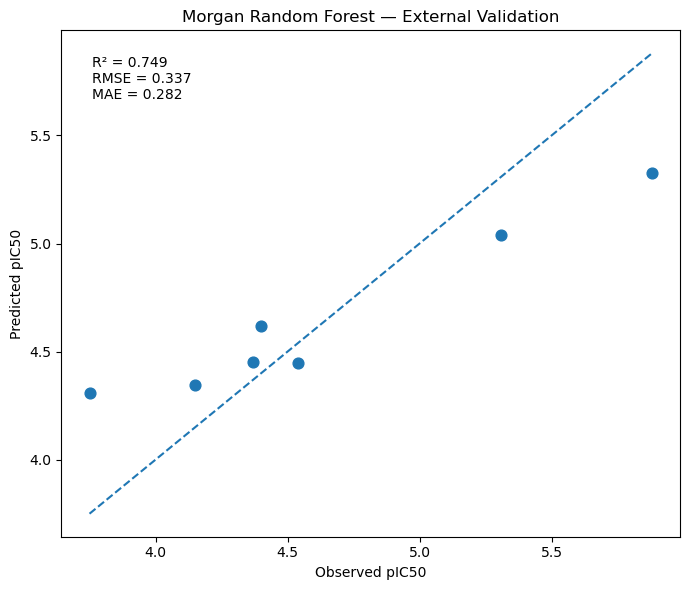

In [195]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_rf_external,
    s=60
)

# Ideal prediction line
min_val = min(y_test.min(), y_rf_external.min())
max_val = max(y_test.max(), y_rf_external.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed pIC50")
plt.ylabel("Predicted pIC50")

plt.title(
    "Morgan Random Forest — External Validation"
)

plt.text(
    0.05,
    0.95,
    f"R² = {rf_external_r2:.3f}\n"
    f"RMSE = {rf_external_rmse:.3f}\n"
    f"MAE = {rf_external_mae:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.savefig(
    "Figure_Morgan_RF_External_Validation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

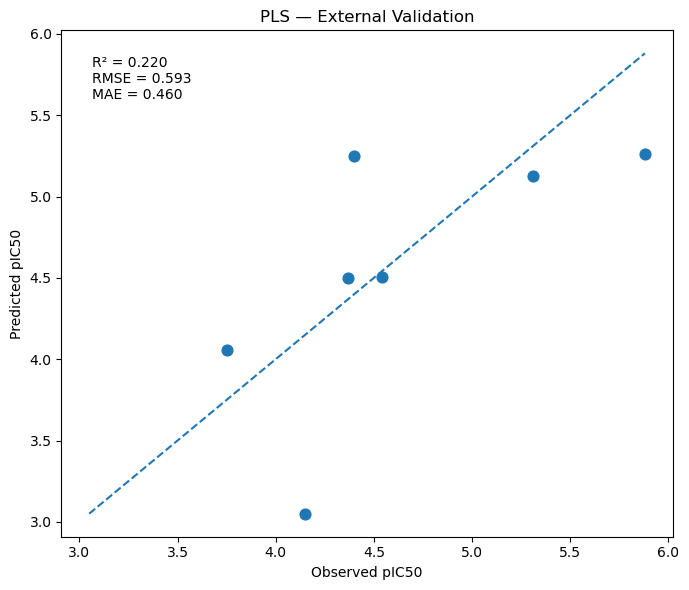

In [192]:
y_pls_external = external_results["Predicted_pIC50"].values

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pls_external,
    s=60
)

min_val = min(y_test.min(), y_pls_external.min())
max_val = max(y_test.max(), y_pls_external.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed pIC50")
plt.ylabel("Predicted pIC50")

plt.title(
    "PLS — External Validation"
)

plt.text(
    0.05,
    0.95,
    f"R² = {r2_score(y_test, y_pls_external):.3f}\n"
    f"RMSE = {np.sqrt(mean_squared_error(y_test, y_pls_external)):.3f}\n"
    f"MAE = {mean_absolute_error(y_test, y_pls_external):.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()

plt.savefig("PLS External Validation.png", dpi=300, bbox_inches="tight")

plt.show()

# Step 6I — Prospective Prediction of New Synthesized Compounds

In [168]:
# Load newly synthesized compounds

new_df = pd.read_excel(
    "New Synthesized Compounds.xlsx"
)

print("Number of new compounds:", len(new_df))
print(new_df.head())

Number of new compounds: 21
    ID                                    SMILES
0  KR1                CC(C1=CC2=CC=CC=C2OC1=O)=O
1  KR2             CC(C1=CC2=CC(C)=CC=C2OC1=O)=O
2  KR3            CC(C1=CC2=CC(OC)=CC=C2OC1=O)=O
3  KR4  CC(C1=CC2=CC([N+]([O-])=O)=CC=C2OC1=O)=O
4  KR5            CC(C1=CC2=CC(Cl)=CC=C2OC1=O)=O


In [169]:
print("Missing IDs:", new_df["ID"].isna().sum())
print("Missing SMILES:", new_df["SMILES"].isna().sum())

Missing IDs: 0
Missing SMILES: 0


In [170]:
# Convert SMILES to RDKit molecules

new_df["Mol"] = new_df["SMILES"].apply(Chem.MolFromSmiles)

print("Valid molecules:", new_df["Mol"].notna().sum())
print("Invalid molecules:", new_df["Mol"].isna().sum())

Valid molecules: 21
Invalid molecules: 0


In [171]:
print(new_df[["ID", "SMILES", "Mol"]].head())

    ID                                    SMILES  \
0  KR1                CC(C1=CC2=CC=CC=C2OC1=O)=O   
1  KR2             CC(C1=CC2=CC(C)=CC=C2OC1=O)=O   
2  KR3            CC(C1=CC2=CC(OC)=CC=C2OC1=O)=O   
3  KR4  CC(C1=CC2=CC([N+]([O-])=O)=CC=C2OC1=O)=O   
4  KR5            CC(C1=CC2=CC(Cl)=CC=C2OC1=O)=O   

                                                Mol  
0  <rdkit.Chem.rdchem.Mol object at 0x7e3792c195b0>  
1  <rdkit.Chem.rdchem.Mol object at 0x7e3792c1a880>  
2  <rdkit.Chem.rdchem.Mol object at 0x7e3792c1ad50>  
3  <rdkit.Chem.rdchem.Mol object at 0x7e3792c1a1f0>  
4  <rdkit.Chem.rdchem.Mol object at 0x7e3792c19e00>  


In [172]:
# Generate Morgan fingerprints for new compounds
# Use EXACTLY the same settings as the trained model

new_morgan_fps = [
    morgan_generator.GetFingerprint(mol)
    for mol in new_df["Mol"]
]

print("Number of new fingerprints:", len(new_morgan_fps))
print("Fingerprint size:", new_morgan_fps[0].GetNumBits())

Number of new fingerprints: 21
Fingerprint size: 2048


In [173]:
# Convert new Morgan fingerprints to NumPy matrix

X_new_morgan = np.array([
    list(fp)
    for fp in new_morgan_fps
])

print("New Morgan fingerprint matrix:", X_new_morgan.shape)

New Morgan fingerprint matrix: (21, 2048)


# Step 6I-3 — Applicability Domain by Morgan similarity

In [174]:
from rdkit import DataStructs

# Morgan fingerprints of the 27 training compounds
training_morgan_fps = [
    morgan_fps[i]
    for i in train_df.index
]

# Calculate similarity of each new compound to all training compounds
new_similarity_results = []

for idx, new_fp in enumerate(new_morgan_fps):

    similarities = [
        DataStructs.TanimotoSimilarity(
            new_fp,
            train_fp
        )
        for train_fp in training_morgan_fps
    ]

    new_similarity_results.append({
        "ID": new_df.loc[idx, "ID"],
        "Max_Tanimoto_to_Training": max(similarities),
        "Mean_Tanimoto_to_Training": np.mean(similarities)
    })

new_similarity_df = pd.DataFrame(
    new_similarity_results
)

print(new_similarity_df)

      ID  Max_Tanimoto_to_Training  Mean_Tanimoto_to_Training
0    KR1                  0.294118                   0.217498
1    KR2                  0.259259                   0.193604
2    KR3                  0.322581                   0.211867
3    KR4                  0.263889                   0.184362
4    KR5                  0.290323                   0.197355
5    KR6                  0.259259                   0.192747
6    KR7                  0.254545                   0.191270
7    KR8                  0.261538                   0.181987
8    KR9                  0.264706                   0.166665
9   KR10                  0.283784                   0.182607
10  KR11                  0.246575                   0.160555
11  KR12                  0.260870                   0.170176
12  KR13                  0.260870                   0.166270
13  KR14                  0.260870                   0.165097
14  KR15                  0.246377                   0.171230
15  KR16

# Step 6I-4 — Add an AD flag

In [175]:
# Training-set minimum nearest-neighbor similarity
training_nn_min = np.min(train_max_similarity)

print("Training minimum nearest-neighbor similarity:",
      training_nn_min)

# Applicability-domain flag
new_similarity_df["AD_Flag"] = np.where(
    new_similarity_df["Max_Tanimoto_to_Training"] >= training_nn_min,
    "Within observed training similarity range",
    "Below observed training similarity range"
)

print(
    new_similarity_df.sort_values(
        "Max_Tanimoto_to_Training",
        ascending=False
    )
)

Training minimum nearest-neighbor similarity: 0.27586206896551724
      ID  Max_Tanimoto_to_Training  Mean_Tanimoto_to_Training  \
2    KR3                  0.322581                   0.211867   
0    KR1                  0.294118                   0.217498   
4    KR5                  0.290323                   0.197355   
9   KR10                  0.283784                   0.182607   
15  KR16                  0.272727                   0.162656   
8    KR9                  0.264706                   0.166665   
3    KR4                  0.263889                   0.184362   
7    KR8                  0.261538                   0.181987   
12  KR13                  0.260870                   0.166270   
13  KR14                  0.260870                   0.165097   
11  KR12                  0.260870                   0.170176   
1    KR2                  0.259259                   0.193604   
5    KR6                  0.259259                   0.192747   
6    KR7                

# Step 6I-5 — Find the nearest training compound

In [176]:
nearest_training_results = []

for idx, new_fp in enumerate(new_morgan_fps):

    similarities = [
        DataStructs.TanimotoSimilarity(
            new_fp,
            train_fp
        )
        for train_fp in training_morgan_fps
    ]

    nearest_idx = np.argmax(similarities)

    nearest_training_results.append({
        "ID": new_df.loc[idx, "ID"],
        "Nearest_Training_Compound": train_df.loc[
            train_df.index[nearest_idx],
            "Compound"
        ],
        "Nearest_Tanimoto": similarities[nearest_idx]
    })

nearest_training_df = pd.DataFrame(
    nearest_training_results
)

# Merge with AD results
new_similarity_df = new_similarity_df.merge(
    nearest_training_df,
    on="ID"
)

print(
    new_similarity_df.sort_values(
        "Max_Tanimoto_to_Training",
        ascending=False
    )
)

      ID  Max_Tanimoto_to_Training  Mean_Tanimoto_to_Training  \
2    KR3                  0.322581                   0.211867   
0    KR1                  0.294118                   0.217498   
4    KR5                  0.290323                   0.197355   
9   KR10                  0.283784                   0.182607   
15  KR16                  0.272727                   0.162656   
8    KR9                  0.264706                   0.166665   
3    KR4                  0.263889                   0.184362   
7    KR8                  0.261538                   0.181987   
12  KR13                  0.260870                   0.166270   
13  KR14                  0.260870                   0.165097   
11  KR12                  0.260870                   0.170176   
1    KR2                  0.259259                   0.193604   
5    KR6                  0.259259                   0.192747   
6    KR7                  0.254545                   0.191270   
20  KR21                 

# Step 6I-6 — Predict pIC₅₀ for the 21 new compounds

In [177]:
# ============================================================
# Step 6I-6 — Prospective pIC50 Prediction
# Morgan Random Forest
# ============================================================

# Predict pIC50 for the 21 new synthesized compounds
new_predicted_pIC50 = rf_morgan.predict(X_new_morgan)

# Add predictions to the AD table
new_similarity_df["Predicted_pIC50"] = new_predicted_pIC50

# Sort by predicted activity
new_prediction_results = new_similarity_df.sort_values(
    "Predicted_pIC50",
    ascending=False
).reset_index(drop=True)

print(new_prediction_results)

      ID  Max_Tanimoto_to_Training  Mean_Tanimoto_to_Training  \
0   KR18                  0.240000                   0.148925   
1   KR11                  0.246575                   0.160555   
2   KR19                  0.253521                   0.157521   
3   KR16                  0.272727                   0.162656   
4   KR21                  0.253521                   0.152956   
5   KR20                  0.253521                   0.154002   
6    KR4                  0.263889                   0.184362   
7   KR12                  0.260870                   0.170176   
8   KR15                  0.246377                   0.171230   
9    KR9                  0.264706                   0.166665   
10  KR14                  0.260870                   0.165097   
11   KR8                  0.261538                   0.181987   
12  KR13                  0.260870                   0.166270   
13   KR2                  0.259259                   0.193604   
14   KR5                 

In [178]:
# ============================================================
# Step 6I-7 — Random Forest Prediction Dispersion
# ============================================================

# Predictions from individual trees
tree_predictions = np.array([
    tree.predict(X_new_morgan)
    for tree in rf_morgan.estimators_
])

# Mean and standard deviation across trees
new_similarity_df["RF_Prediction_Mean"] = np.mean(
    tree_predictions,
    axis=0
)

new_similarity_df["RF_Prediction_SD"] = np.std(
    tree_predictions,
    axis=0
)

# Sort by predicted activity
new_uncertainty_results = new_similarity_df.sort_values(
    "RF_Prediction_Mean",
    ascending=False
).reset_index(drop=True)

print(
    new_uncertainty_results[
        [
            "ID",
            "RF_Prediction_Mean",
            "RF_Prediction_SD",
            "Max_Tanimoto_to_Training",
            "AD_Flag"
        ]
    ]
)

      ID  RF_Prediction_Mean  RF_Prediction_SD  Max_Tanimoto_to_Training  \
0   KR18             5.04222          0.613826                  0.240000   
1   KR11             5.00904          0.614339                  0.246575   
2   KR19             4.98160          0.640261                  0.253521   
3   KR16             4.97862          0.635147                  0.272727   
4   KR21             4.97312          0.641040                  0.253521   
5   KR20             4.97224          0.641531                  0.253521   
6    KR4             4.96764          0.536273                  0.263889   
7   KR12             4.94058          0.638009                  0.260870   
8   KR15             4.93244          0.636484                  0.246377   
9    KR9             4.93154          0.636637                  0.264706   
10  KR14             4.92694          0.641171                  0.260870   
11   KR8             4.92394          0.627591                  0.261538   
12  KR13    

In [179]:
final_new_compounds = new_similarity_df[
    [
        "ID",
        "Predicted_pIC50",
        "RF_Prediction_SD",
        "Max_Tanimoto_to_Training",
        "Mean_Tanimoto_to_Training",
        "Nearest_Training_Compound",
        "Nearest_Tanimoto",
        "AD_Flag"
    ]
].copy()

final_new_compounds = final_new_compounds.sort_values(
    "Predicted_pIC50",
    ascending=False
).reset_index(drop=True)

print(final_new_compounds)

      ID  Predicted_pIC50  RF_Prediction_SD  Max_Tanimoto_to_Training  \
0   KR18          5.04222          0.613826                  0.240000   
1   KR11          5.00904          0.614339                  0.246575   
2   KR19          4.98160          0.640261                  0.253521   
3   KR16          4.97862          0.635147                  0.272727   
4   KR21          4.97312          0.641040                  0.253521   
5   KR20          4.97224          0.641531                  0.253521   
6    KR4          4.96764          0.536273                  0.263889   
7   KR12          4.94058          0.638009                  0.260870   
8   KR15          4.93244          0.636484                  0.246377   
9    KR9          4.93154          0.636637                  0.264706   
10  KR14          4.92694          0.641171                  0.260870   
11   KR8          4.92394          0.627591                  0.261538   
12  KR13          4.92162          0.644637        

In [180]:
final_new_compounds.to_excel(
    "Morgan_RF_Prospective_Predictions_KR1_KR21.xlsx",
    index=False
)

print("Final prospective prediction results saved.")

Final prospective prediction results saved.


# # Step 8 — Final Model Selection and Performance Comparison

In [181]:
# Final model comparison: CV Q2 vs External R2

comparison_plot = final_model_comparison[
    final_model_comparison["External_R2"].notna()
].copy()

print(comparison_plot)

                      Model     CV_Q2   CV_RMSE    CV_MAE  External_R2  \
2         PLS (1 component)  0.372989  0.529757  0.397692     0.230688   
5      Morgan Random Forest  0.437775  0.501642  0.382651     0.748895   
6  Morgan Gradient Boosting  0.493981  0.475907  0.345342     0.443301   

   External_RMSE  External_MAE  
2       0.589153      0.456350  
5       0.336592      0.281671  
6       0.501172      0.430689  


In [182]:
print(final_new_compounds.columns.tolist())

['ID', 'Predicted_pIC50', 'RF_Prediction_SD', 'Max_Tanimoto_to_Training', 'Mean_Tanimoto_to_Training', 'Nearest_Training_Compound', 'Nearest_Tanimoto', 'AD_Flag']


In [183]:
print(final_model_comparison)

                      Model     CV_Q2   CV_RMSE    CV_MAE  External_R2  \
0                     LASSO  0.120772  0.627732  0.495586          NaN   
1               Elastic Net  0.209227  0.594928  0.457251          NaN   
2         PLS (1 component)  0.372989  0.529757  0.397692     0.230688   
3  Descriptor Random Forest  0.314047  0.554097  0.422590          NaN   
4            Descriptor SVR  0.244486  0.581514  0.474379          NaN   
5      Morgan Random Forest  0.437775  0.501642  0.382651     0.748895   
6  Morgan Gradient Boosting  0.493981  0.475907  0.345342     0.443301   
7                Morgan SVR  0.335401  0.545404  0.427722          NaN   

   External_RMSE  External_MAE  
0            NaN           NaN  
1            NaN           NaN  
2       0.589153      0.456350  
3            NaN           NaN  
4            NaN           NaN  
5       0.336592      0.281671  
6       0.501172      0.430689  
7            NaN           NaN  


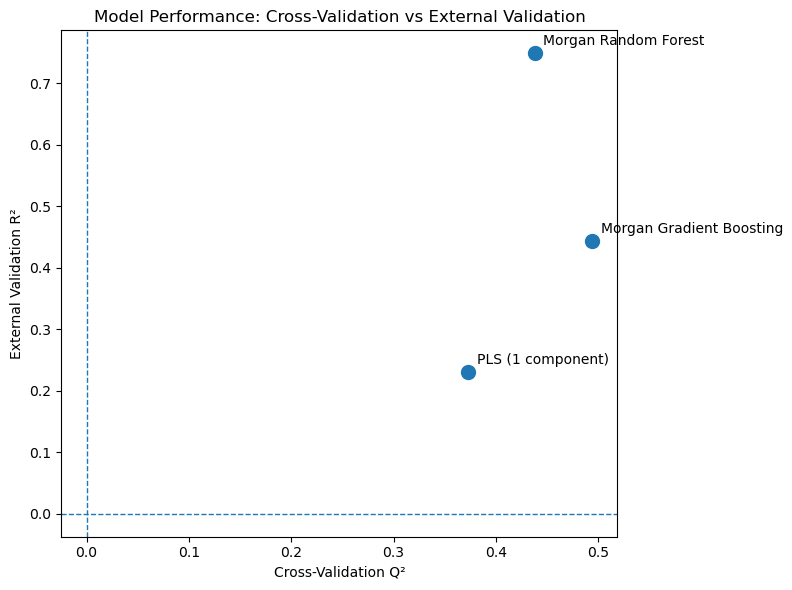

In [193]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    comparison_plot["CV_Q2"],
    comparison_plot["External_R2"],
    s=100
)

for _, row in comparison_plot.iterrows():
    plt.annotate(
        row["Model"],
        (row["CV_Q2"], row["External_R2"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Cross-Validation Q²")
plt.ylabel("External Validation R²")
plt.title("Model Performance: Cross-Validation vs External Validation")

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.tight_layout()

plt.savefig("Model Performance: Cross-Validation vs External Validation.png", dpi=300, bbox_inches="tight")

plt.show()

In [185]:
# ============================================================
# STEP 9 — Final QSAR/ML Summary
# ============================================================

final_model_summary = final_model_comparison.copy()

final_model_summary = final_model_summary.round({
    "CV_Q2": 3,
    "CV_RMSE": 3,
    "CV_MAE": 3,
    "External_R2": 3,
    "External_RMSE": 3,
    "External_MAE": 3
})

print(final_model_summary)

                      Model  CV_Q2  CV_RMSE  CV_MAE  External_R2  \
0                     LASSO  0.121    0.628   0.496          NaN   
1               Elastic Net  0.209    0.595   0.457          NaN   
2         PLS (1 component)  0.373    0.530   0.398        0.231   
3  Descriptor Random Forest  0.314    0.554   0.423          NaN   
4            Descriptor SVR  0.244    0.582   0.474          NaN   
5      Morgan Random Forest  0.438    0.502   0.383        0.749   
6  Morgan Gradient Boosting  0.494    0.476   0.345        0.443   
7                Morgan SVR  0.335    0.545   0.428          NaN   

   External_RMSE  External_MAE  
0            NaN           NaN  
1            NaN           NaN  
2          0.589         0.456  
3            NaN           NaN  
4            NaN           NaN  
5          0.337         0.282  
6          0.501         0.431  
7            NaN           NaN  


In [186]:
final_model_summary.to_excel(
    "Final_QSAR_ML_Model_Comparison.xlsx",
    index=False
)

print("Final model comparison saved.")

Final model comparison saved.


# Step 10A — Create the final prospective-results table

In [198]:
# ============================================================
# STEP 10 — FINAL PROSPECTIVE PREDICTION RESULTS
# ============================================================

final_prospective = final_new_compounds[
    [
        "ID",
        "Predicted_pIC50",
        "RF_Prediction_SD",
        "Max_Tanimoto_to_Training",
        "Mean_Tanimoto_to_Training",
        "Nearest_Training_Compound",
        "Nearest_Tanimoto",
        "AD_Flag"
    ]
].copy()

# Rank compounds according to predicted pIC50
final_prospective["Prediction_Rank"] = (
    final_prospective["Predicted_pIC50"]
    .rank(ascending=False, method="min")
    .astype(int)
)

final_prospective = final_prospective.sort_values(
    "Prediction_Rank"
).reset_index(drop=True)

# Reorder columns
final_prospective = final_prospective[
    [
        "Prediction_Rank",
        "ID",
        "Predicted_pIC50",
        "RF_Prediction_SD",
        "Max_Tanimoto_to_Training",
        "Mean_Tanimoto_to_Training",
        "Nearest_Training_Compound",
        "Nearest_Tanimoto",
        "AD_Flag"
    ]
]

print(final_prospective)

    Prediction_Rank    ID  Predicted_pIC50  RF_Prediction_SD  \
0                 1  KR18          5.04222          0.613826   
1                 2  KR11          5.00904          0.614339   
2                 3  KR19          4.98160          0.640261   
3                 4  KR16          4.97862          0.635147   
4                 5  KR21          4.97312          0.641040   
5                 6  KR20          4.97224          0.641531   
6                 7   KR4          4.96764          0.536273   
7                 8  KR12          4.94058          0.638009   
8                 9  KR15          4.93244          0.636484   
9                10   KR9          4.93154          0.636637   
10               11  KR14          4.92694          0.641171   
11               12   KR8          4.92394          0.627591   
12               13  KR13          4.92162          0.644637   
13               14   KR2          4.89664          0.554871   
14               15   KR5          4.894

# Step 10B — Create a more useful interpretation category

In [199]:
# Training-set minimum nearest-neighbor similarity
training_similarity_threshold = np.min(train_max_similarity)

def classify_ad(max_tanimoto):
    if max_tanimoto >= training_similarity_threshold:
        return "Supported by observed training space"
    elif max_tanimoto >= 0.25:
        return "Below observed range — caution"
    else:
        return "Low similarity — strong caution"

final_prospective["Prediction_Support"] = (
    final_prospective["Max_Tanimoto_to_Training"]
    .apply(classify_ad)
)

print(
    final_prospective[
        [
            "Prediction_Rank",
            "ID",
            "Predicted_pIC50",
            "Max_Tanimoto_to_Training",
            "Prediction_Support"
        ]
    ]
)

    Prediction_Rank    ID  Predicted_pIC50  Max_Tanimoto_to_Training  \
0                 1  KR18          5.04222                  0.240000   
1                 2  KR11          5.00904                  0.246575   
2                 3  KR19          4.98160                  0.253521   
3                 4  KR16          4.97862                  0.272727   
4                 5  KR21          4.97312                  0.253521   
5                 6  KR20          4.97224                  0.253521   
6                 7   KR4          4.96764                  0.263889   
7                 8  KR12          4.94058                  0.260870   
8                 9  KR15          4.93244                  0.246377   
9                10   KR9          4.93154                  0.264706   
10               11  KR14          4.92694                  0.260870   
11               12   KR8          4.92394                  0.261538   
12               13  KR13          4.92162                  0.26

# Step 10C — Identify the strongest candidates with AD support

In [200]:
# Compounds within the observed training similarity range
supported_candidates = final_prospective[
    final_prospective["Max_Tanimoto_to_Training"]
    >= training_similarity_threshold
].copy()

print("Compounds within observed training similarity range:")
print(
    supported_candidates[
        [
            "Prediction_Rank",
            "ID",
            "Predicted_pIC50",
            "RF_Prediction_SD",
            "Max_Tanimoto_to_Training",
            "Nearest_Training_Compound",
            "Nearest_Tanimoto"
        ]
    ]
)

Compounds within observed training similarity range:
    Prediction_Rank    ID  Predicted_pIC50  RF_Prediction_SD  \
14               15   KR5          4.89438          0.558054   
18               19   KR1          4.84870          0.560733   
19               20  KR10          4.83292          0.625064   
20               21   KR3          4.78100          0.534308   

    Max_Tanimoto_to_Training Nearest_Training_Compound  Nearest_Tanimoto  
14                  0.290323                       K19          0.290323  
18                  0.294118                        K7          0.294118  
19                  0.283784                       K21          0.283784  
20                  0.322581                       K21          0.322581  


# Step 10D — Identify the highest predicted compounds

In [201]:
top_predicted = final_prospective.head(10)

print(
    top_predicted[
        [
            "Prediction_Rank",
            "ID",
            "Predicted_pIC50",
            "RF_Prediction_SD",
            "Max_Tanimoto_to_Training",
            "Prediction_Support"
        ]
    ]
)

   Prediction_Rank    ID  Predicted_pIC50  RF_Prediction_SD  \
0                1  KR18          5.04222          0.613826   
1                2  KR11          5.00904          0.614339   
2                3  KR19          4.98160          0.640261   
3                4  KR16          4.97862          0.635147   
4                5  KR21          4.97312          0.641040   
5                6  KR20          4.97224          0.641531   
6                7   KR4          4.96764          0.536273   
7                8  KR12          4.94058          0.638009   
8                9  KR15          4.93244          0.636484   
9               10   KR9          4.93154          0.636637   

   Max_Tanimoto_to_Training               Prediction_Support  
0                  0.240000  Low similarity — strong caution  
1                  0.246575  Low similarity — strong caution  
2                  0.253521   Below observed range — caution  
3                  0.272727   Below observed range — c

# Step 10E — Save the final table

In [202]:
final_prospective.to_excel(
    "Final_Prospective_KR1_KR21_Morgan_RF.xlsx",
    index=False
)

print("Final prospective results saved.")

Final prospective results saved.
